<a href="https://colab.research.google.com/github/praveen-kumar-01/Household_Size_Analysis_and_Prediction/blob/main/Household_Size_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier


df = pd.read_csv("avg-household-size.csv")


print(df.head())
print(df.info())
print(df.describe())

   statefips  countyfips  avghouseholdsize                           geography
0          2          13              2.43      Aleutians East Borough, Alaska
1          2          16              3.59  Aleutians West Census Area, Alaska
2          2          20              2.77      Anchorage Municipality, Alaska
3          2          50              3.86          Bethel Census Area, Alaska
4          2          60              2.50         Bristol Bay Borough, Alaska
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3220 entries, 0 to 3219
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   statefips         3220 non-null   int64  
 1   countyfips        3220 non-null   int64  
 2   avghouseholdsize  3220 non-null   float64
 3   geography         3220 non-null   object 
dtypes: float64(1), int64(2), object(1)
memory usage: 100.8+ KB
None
         statefips   countyfips  avghouseholdsize
count  3220.000000 

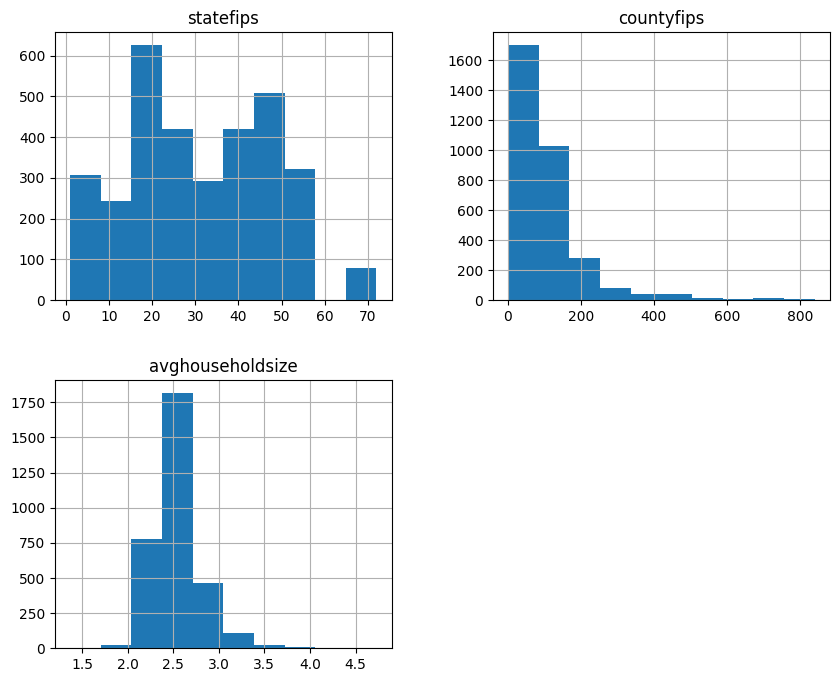

In [3]:
df.hist(figsize=(10,8))
plt.show()

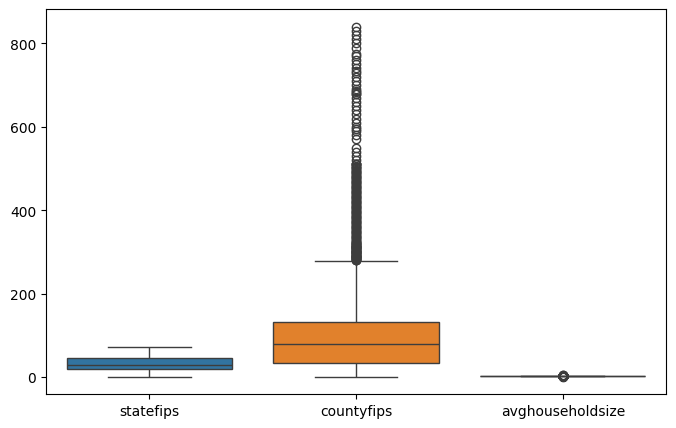

In [4]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df.select_dtypes(include=np.number))
plt.show()

In [5]:
print("First 5 rows:")
print(df.head())

First 5 rows:
   statefips  countyfips  avghouseholdsize                           geography
0          2          13              2.43      Aleutians East Borough, Alaska
1          2          16              3.59  Aleutians West Census Area, Alaska
2          2          20              2.77      Anchorage Municipality, Alaska
3          2          50              3.86          Bethel Census Area, Alaska
4          2          60              2.50         Bristol Bay Borough, Alaska


In [6]:
print("\nColumns:")
print(df.columns)


Columns:
Index(['statefips', 'countyfips', 'avghouseholdsize', 'geography'], dtype='object')


In [7]:
print("\nInfo:")
print(df.info())


Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3220 entries, 0 to 3219
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   statefips         3220 non-null   int64  
 1   countyfips        3220 non-null   int64  
 2   avghouseholdsize  3220 non-null   float64
 3   geography         3220 non-null   object 
dtypes: float64(1), int64(2), object(1)
memory usage: 100.8+ KB
None


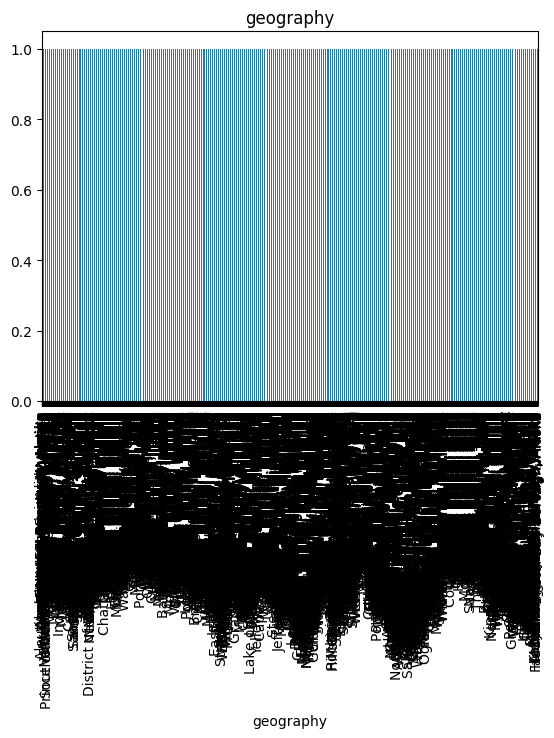

In [8]:
for col in df.select_dtypes(include='object').columns:
    df[col].value_counts().plot(kind='bar')
    plt.title(col)
    plt.show()

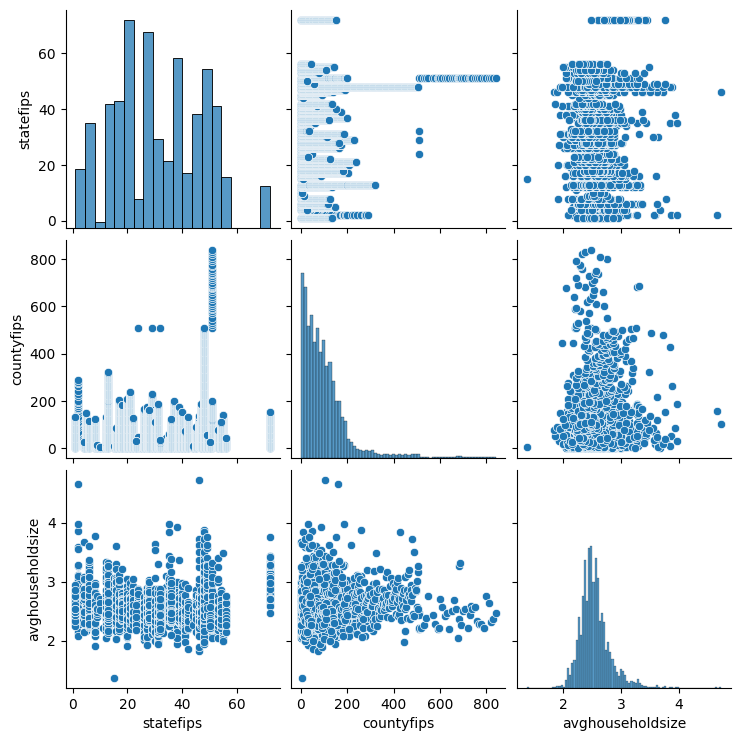

In [9]:
sns.pairplot(df)
plt.show()

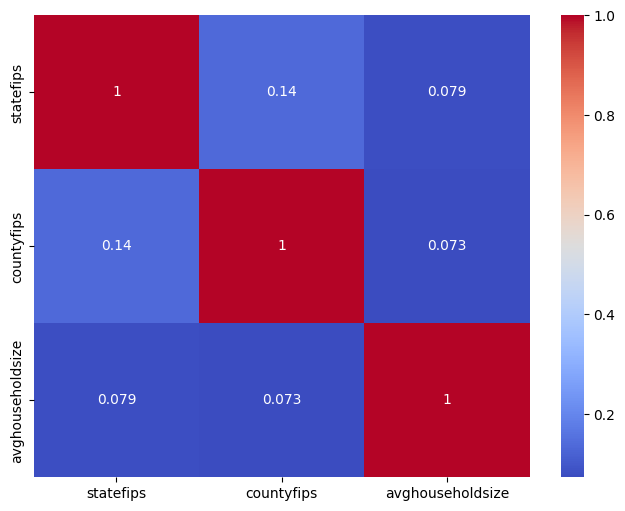

In [10]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [11]:
if len(df.select_dtypes(include='object').columns) >= 2:
    cols = df.select_dtypes(include='object').columns
    print(pd.crosstab(df[cols[0]], df[cols[1]]))

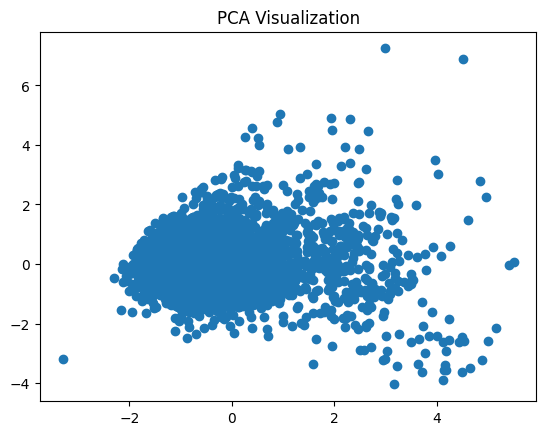

In [12]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

num_df = df.select_dtypes(include=np.number).dropna()

scaler = StandardScaler()
scaled = scaler.fit_transform(num_df)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled)

plt.scatter(pca_result[:,0], pca_result[:,1])
plt.title("PCA Visualization")
plt.show()

In [13]:
print(df.isnull().sum())


df.fillna(df.mean(numeric_only=True), inplace=True)

statefips           0
countyfips          0
avghouseholdsize    0
geography           0
dtype: int64


In [14]:

le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [15]:
print("Mean:\n", df.mean())
print("Median:\n", df.median())
print("Std Dev:\n", df.std())

Mean:
 statefips             31.290683
countyfips           102.922050
avghouseholdsize       2.540755
geography           1609.500000
dtype: float64
Median:
 statefips             30.00
countyfips            79.00
avghouseholdsize       2.51
geography           1609.50
dtype: float64
Std Dev:
 statefips            16.277207
countyfips          106.693846
avghouseholdsize      0.267654
geography           929.678260
dtype: float64


In [16]:

cat_cols = df.select_dtypes(include='object').columns

if len(cat_cols) > 0:
    df[cat_cols[0]].value_counts().plot.pie(autopct='%1.1f%%')
    plt.title(cat_cols[0])
    plt.show()

In [17]:
from sklearn.metrics import r2_score, mean_squared_error
X = df.iloc[:, :-1]
y = df.iloc[:, -1]
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MSE: 55371.16527670807
RMSE: 235.31078444624688
R2 Score: 0.9360989372351962
